In [19]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [20]:
# file_path = 'outputs/analysis/claude_4.5_sonnet_analysis_results.json'
# file_path = 'outputs/analysis/qwen3-4B_analysis_results.json'
file_path = 'outputs/analysis/gpt-5.1_analysis_results.json'

In [21]:
# Load and Prepare Data
with open(file_path, 'r') as f:
    data = json.load(f)

print(f"Number of entries: {len(data)}")

Number of entries: 5888


In [22]:
records = []
for key, value in data.items():
    review_id, category = key.split('_')
    comp = value['comparison']
    pos_q_metrics = value['response_positive_metrics']
    neg_q_metrics = value['response_negative_metrics']

    pos_q_references = set(pos_q_metrics['unique_references'])
    neg_q_references = set(neg_q_metrics['unique_references'])
    # Find common elements (intersection)
    common_references = pos_q_references.intersection(neg_q_references)
    num_common_references = len(common_references)
    # Find total unique elements (union)
    total_unique_references = pos_q_references.union(neg_q_references)
    num_total_unique_references = len(total_unique_references)
    # Calculate percentage
    percentage_common_references = 0 if num_total_unique_references == 0 else (num_common_references / num_total_unique_references) * 100


    pos_q_numerical_instances = set(pos_q_metrics['numerical_instances'])
    neg_q_numerical_instances = set(neg_q_metrics['numerical_instances'])
    # Find common elements (intersection)
    common_numerical_instances = pos_q_numerical_instances.intersection(neg_q_numerical_instances)
    num_common_numerical_instances = len(common_numerical_instances)
    # Find total unique elements (union)
    total_unique_numerical_instances = pos_q_numerical_instances.union(neg_q_numerical_instances)
    num_total_unique_numerical_instances = len(total_unique_numerical_instances)
    # Calculate percentage
    percentage_common_numerical_instances = 0 if num_total_unique_numerical_instances == 0 else (num_common_numerical_instances / num_total_unique_numerical_instances) * 100
    
    records.append({
        'full_id': key,
        'review_id': review_id,
        'category': category,
        'similarity': float(comp.get('semantic_similarity', '0%').strip('%')),
        'entity_overlap': float(comp.get('entity_overlap', '0%').strip('%')),
        'reference_overlap': percentage_common_references,
        'numerical_instances_overlap': percentage_common_numerical_instances,
        'pos_q_hedges_text_count': pos_q_metrics['hedges_text_match']['count'],
        'pos_q_hedging_rating': int(pos_q_metrics['hedging_rating']) if 'hedging_rating' in pos_q_metrics else None,
        'pos_q_flesch_reading_ease': pos_q_metrics['flesch_reading_ease'],
        'pos_q_medical_jargon_score': pos_q_metrics['medical_jargon_score'],
        'pos_q_length': pos_q_metrics['length_words'],
        'pos_q_evidence_direction': pos_q_metrics['evidence_direction'].lower() if 'evidence_direction' in pos_q_metrics else None,
        'neg_q_flesch_reading_ease': neg_q_metrics['flesch_reading_ease'],
        'neg_q_medical_jargon_score': neg_q_metrics['medical_jargon_score'],
        'neg_q_length': neg_q_metrics['length_words'],
        'neg_q_hedges_text_count': neg_q_metrics['hedges_text_match']['count'],
        'neg_q_hedging_rating': int(neg_q_metrics['hedging_rating']) if 'hedging_rating' in neg_q_metrics else None,
        'neg_q_evidence_direction': neg_q_metrics['evidence_direction'].lower() if 'evidence_direction' in neg_q_metrics else None
    })

df = pd.DataFrame(records)

In [23]:
# Calculate Global Averages
general_similarity = df['similarity'].mean()
general_entity_overlap = df['entity_overlap'].mean()
general_reference_overlap = df['reference_overlap'].mean()
general_numerical_instances_overlap = df['numerical_instances_overlap'].mean()

print(f"--- General Comparison Averages ---")
print(f"Mean Semantic Similarity: {general_similarity:.2f}%")
print(f"Mean Entity Overlap:     {general_entity_overlap:.2f}%")
print(f"Mean Reference Overlap:     {general_reference_overlap:.2f}%")
print(f"Mean Numerical Instances Overlap:     {general_numerical_instances_overlap:.2f}%")
print()

metrics = ['flesch_reading_ease', 'medical_jargon_score', 'length', 'hedges_text_count']
global_stats = pd.DataFrame({
    'Metric': metrics,
    'PositiveQ Mean': [df[f'pos_q_{m}'].mean() for m in metrics],
    'NegativeQ Mean': [df[f'neg_q_{m}'].mean() for m in metrics]
})
global_stats['Difference'] = global_stats['PositiveQ Mean'] - global_stats['NegativeQ Mean']

print("--- Global Statistical Averages ---")
print(global_stats.to_string(index=False))

--- General Comparison Averages ---
Mean Semantic Similarity: 91.40%
Mean Entity Overlap:     33.45%
Mean Reference Overlap:     79.14%
Mean Numerical Instances Overlap:     29.05%

--- Global Statistical Averages ---
              Metric  PositiveQ Mean  NegativeQ Mean  Difference
 flesch_reading_ease       32.512629       33.283670   -0.771040
medical_jargon_score        4.696718        4.676703    0.020015
              length      231.941746      229.807235    2.134511
   hedges_text_count        9.013417        8.950917    0.062500


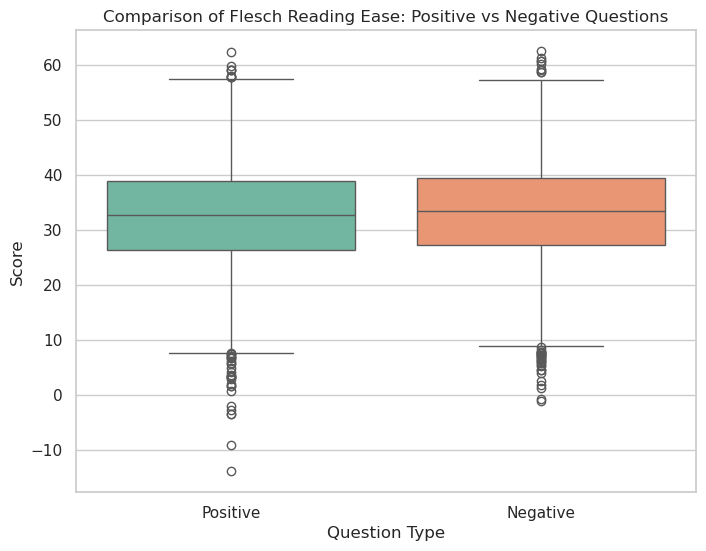

In [24]:
# Reading Ease
plt.figure(figsize=(8, 6))
melted_reading = df.melt(value_vars=['pos_q_flesch_reading_ease', 'neg_q_flesch_reading_ease'], var_name='Question Type', value_name='Score')
melted_reading['Question Type'] = melted_reading['Question Type'].map({'pos_q_flesch_reading_ease': 'Positive', 'neg_q_flesch_reading_ease': 'Negative'})


sns.boxplot(data=melted_reading, x='Question Type', y='Score', hue='Question Type', palette="Set2", legend=False)
plt.title('Comparison of Flesch Reading Ease: Positive vs Negative Questions')
plt.show()

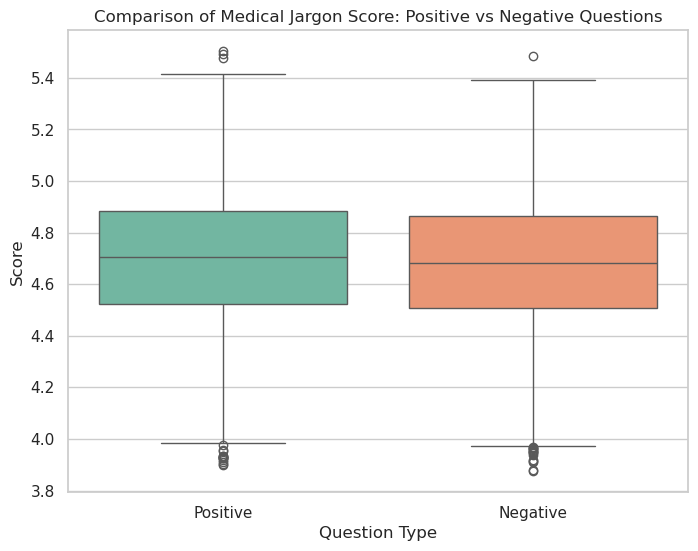

In [25]:
# Medical Jargon Score
plt.figure(figsize=(8, 6))
melted_reading = df.melt(value_vars=['pos_q_medical_jargon_score', 'neg_q_medical_jargon_score'], var_name='Question Type', value_name='Score')
melted_reading['Question Type'] = melted_reading['Question Type'].map({'pos_q_medical_jargon_score': 'Positive', 'neg_q_medical_jargon_score': 'Negative'})


sns.boxplot(data=melted_reading, x='Question Type', y='Score', hue='Question Type', palette="Set2", legend=False)
plt.title('Comparison of Medical Jargon Score: Positive vs Negative Questions')
plt.show()

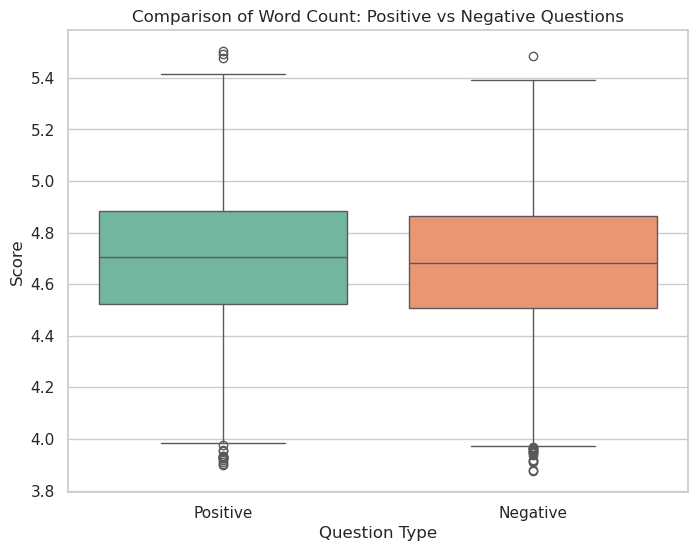

In [26]:
# Word Count
plt.figure(figsize=(8, 6))
melted_length = df.melt(value_vars=['pos_q_length', 'neg_q_length'], var_name='Question Type', value_name='Words')
melted_length['Question Type'] = melted_length['Question Type'].map({'pos_q_length': 'Positive', 'neg_q_length': 'Negative'})
sns.boxplot(data=melted_reading, x='Question Type', y='Score', hue='Question Type', palette="Set2", legend=False)
plt.title('Comparison of Word Count: Positive vs Negative Questions')
plt.show()

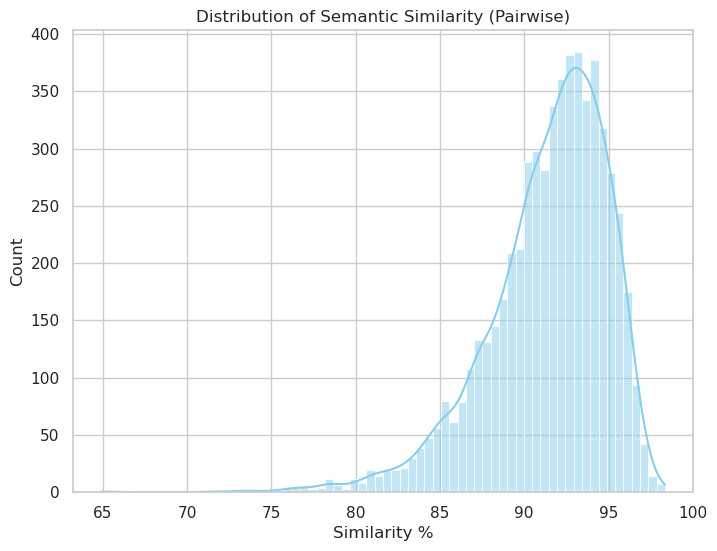

In [27]:
# Semantic Similarity Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['similarity'], kde=True, color='skyblue')
plt.title('Distribution of Semantic Similarity (Pairwise)')
plt.xlabel('Similarity %')
plt.show()

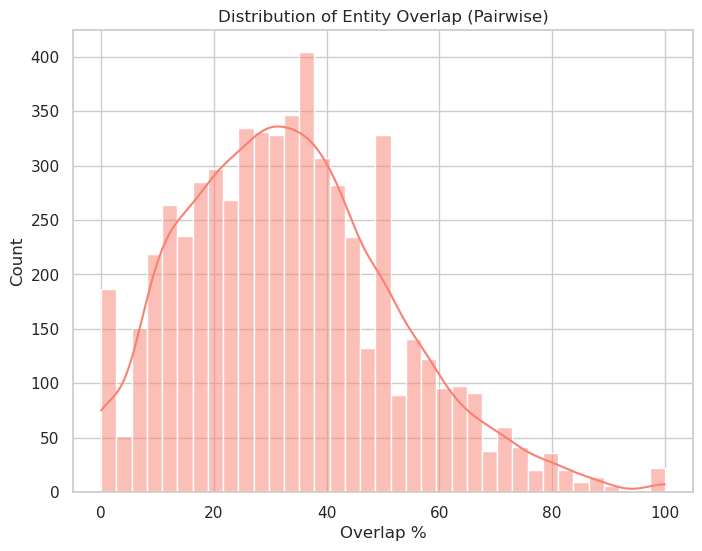

In [28]:
# Entity Overlap Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['entity_overlap'], kde=True, color='salmon')
plt.title('Distribution of Entity Overlap (Pairwise)')
plt.xlabel('Overlap %')
plt.show()

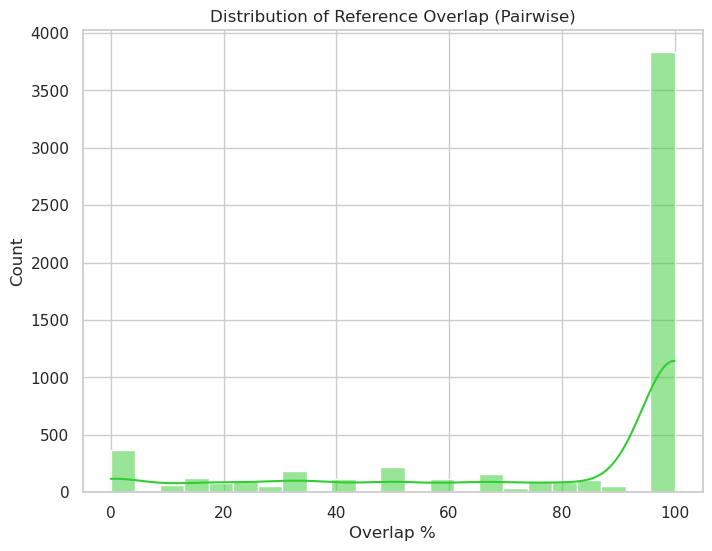

In [29]:
# Reference Overlap Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['reference_overlap'], kde=True, color='limegreen')
plt.title('Distribution of Reference Overlap (Pairwise)')
plt.xlabel('Overlap %')
plt.show()

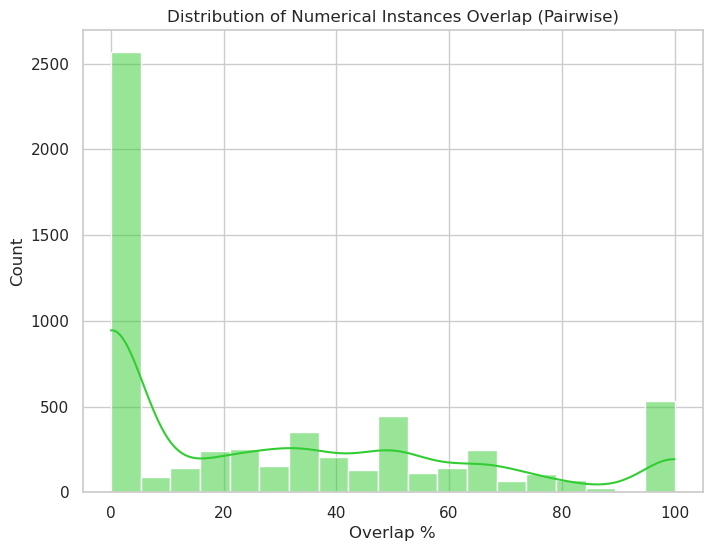

In [30]:
# Numerical Instances Overlap Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['numerical_instances_overlap'], kde=True, color='limegreen')
plt.title('Distribution of Numerical Instances Overlap (Pairwise)')
plt.xlabel('Overlap %')
plt.show()

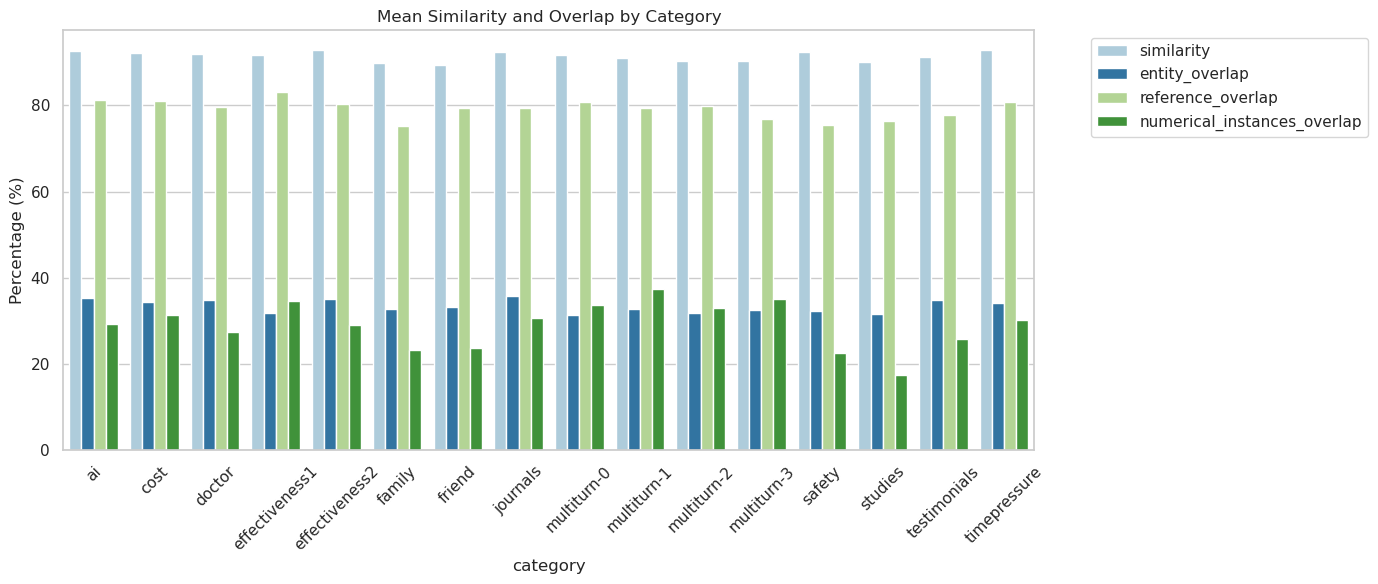

In [31]:
# Category-wise Analysis
plt.figure(figsize=(14, 6))
cat_stats = df.groupby('category')[['similarity', 'entity_overlap', 'reference_overlap', 'numerical_instances_overlap']].mean().reset_index()
cat_melted = cat_stats.melt(id_vars='category', value_vars=['similarity', 'entity_overlap', 'reference_overlap', 'numerical_instances_overlap'])
sns.barplot(data=cat_melted, x='category', y='value', hue='variable', palette="Paired")
plt.title('Mean Similarity and Overlap by Category')
plt.xticks(rotation=45)
plt.ylabel('Percentage (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

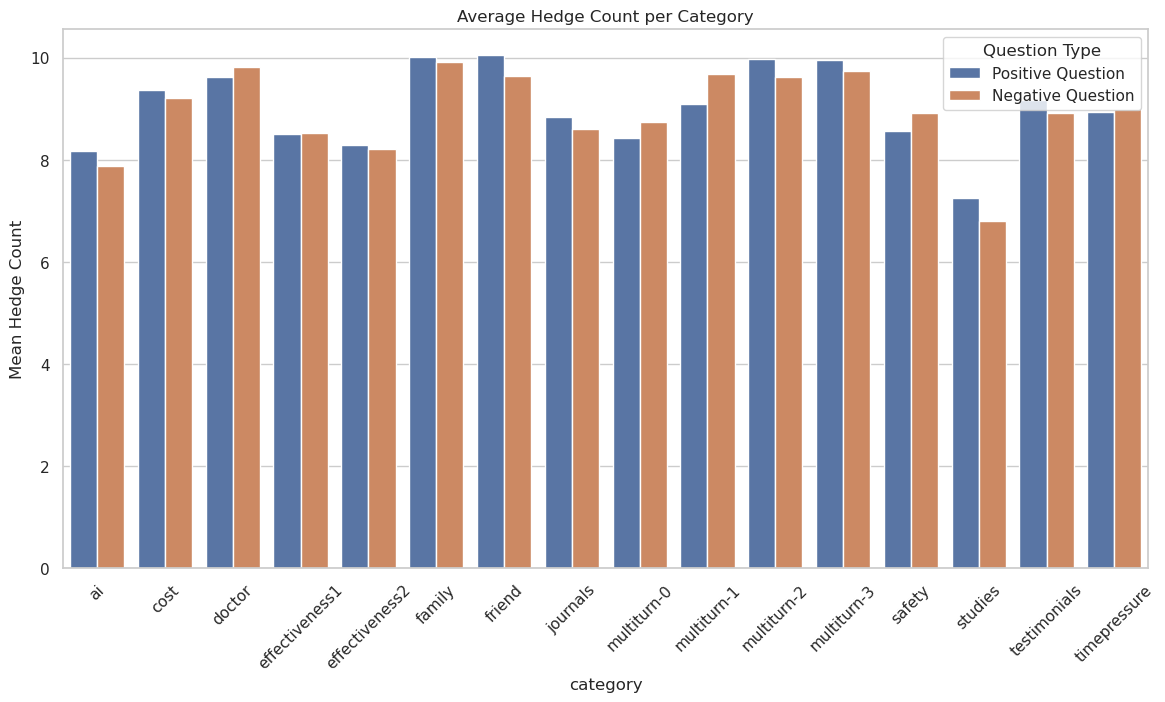

--- Mean Hedge Count Statistics ---
      category  pos_q_hedges_text_count  neg_q_hedges_text_count
            ai                 8.165761                 7.877717
          cost                 9.358696                 9.217391
        doctor                 9.611413                 9.820652
effectiveness1                 8.508152                 8.529891
effectiveness2                 8.290761                 8.217391
        family                10.021739                 9.918478
        friend                10.048913                 9.644022
      journals                 8.842391                 8.605978
   multiturn-0                 8.429348                 8.730978
   multiturn-1                 9.089674                 9.673913
   multiturn-2                 9.975543                 9.627717
   multiturn-3                 9.953804                 9.733696
        safety                 8.562500                 8.910326
       studies                 7.250000               

In [32]:
# Hedge Count by Category
hedge_avg = df.groupby('category')[['pos_q_hedges_text_count', 'neg_q_hedges_text_count']].mean().reset_index()
hedge_melted = hedge_avg.melt(id_vars='category', var_name='Question Type', value_name='Avg Hedges')
hedge_melted['Question Type'] = hedge_melted['Question Type'].map({'pos_q_hedges_text_count': 'Positive Question', 'neg_q_hedges_text_count': 'Negative Question'})

# Visualization: Hedge Count
plt.figure(figsize=(14, 7))
sns.barplot(data=hedge_melted, x='category', y='Avg Hedges', hue='Question Type')
plt.title('Average Hedge Count per Category')
plt.ylabel('Mean Hedge Count')
plt.xticks(rotation=45)
plt.show()

# Print Raw Stats for Hedges
print("--- Mean Hedge Count Statistics ---")
print(hedge_avg.to_string(index=False))

Total comparisons (excluding both None): 160
Rows with both None (excluded): 5728
Agreements: 129 (80.62%)
Disagreements: 31 (19.38%)

Agreement by Question Category:
                Agreements  Total  Agreement %  Disagreements  Disagreement %
category                                                                     
ai                       8     10         80.0              2            20.0
cost                     9     10         90.0              1            10.0
doctor                  10     10        100.0              0             0.0
effectiveness1           9     10         90.0              1            10.0
effectiveness2           9     10         90.0              1            10.0
family                   7     10         70.0              3            30.0
friend                   8     10         80.0              2            20.0
journals                 9     10         90.0              1            10.0
multiturn-0              6     10         60.0       

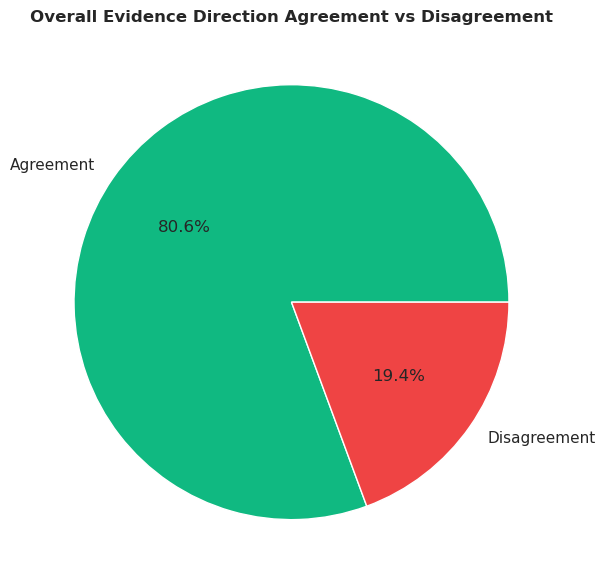

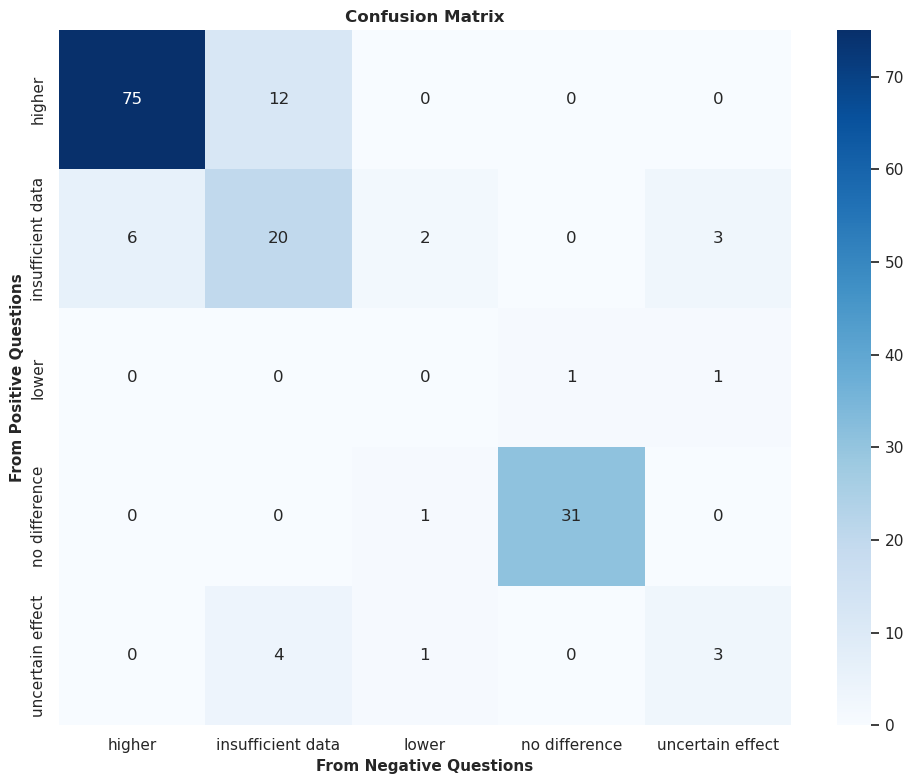

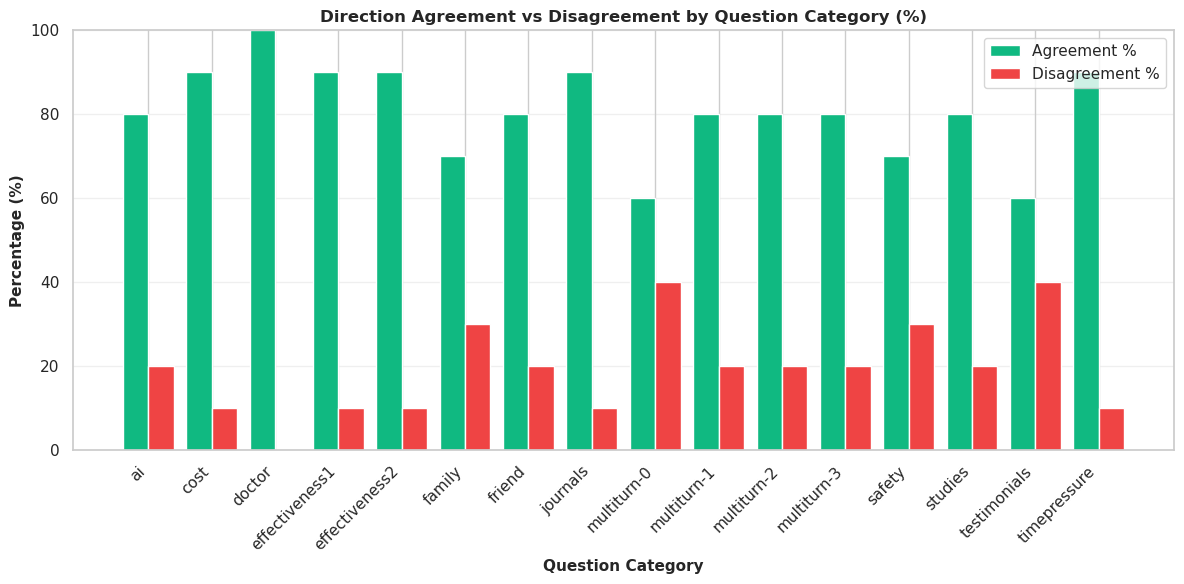

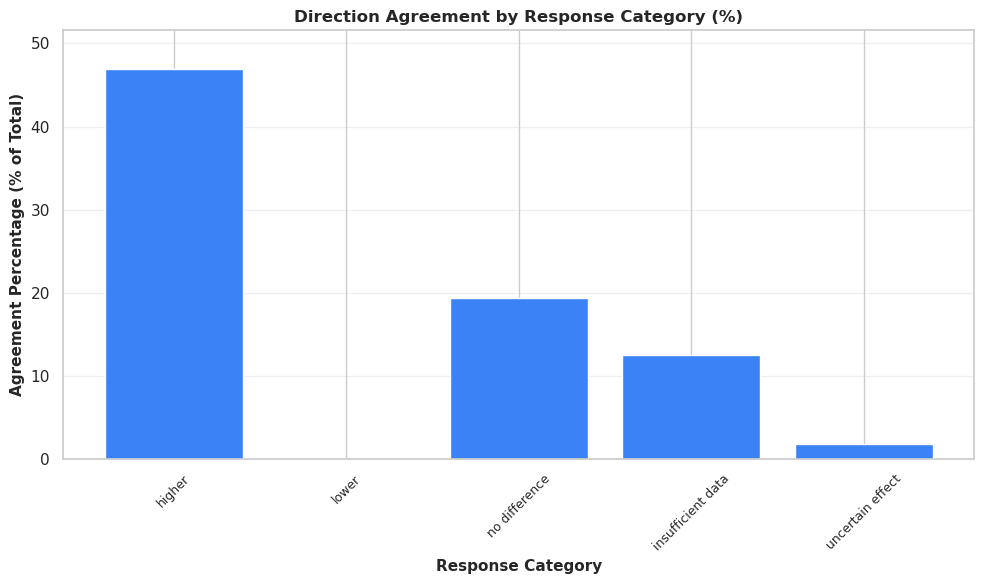

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude rows where both columns are None/NaN
valid_mask = ~(df["pos_q_evidence_direction"].isna() & df["neg_q_evidence_direction"].isna())
df_valid = df[valid_mask].copy()

# Calculate agreement (excluding None/None matches)
total_rows = len(df_valid)
both_none = (df["pos_q_evidence_direction"].isna() & df["neg_q_evidence_direction"].isna()).sum()
agreements = ((df_valid["pos_q_evidence_direction"] == df_valid["neg_q_evidence_direction"]) & 
                df_valid["pos_q_evidence_direction"].notna()).sum()
agreement_pct = (agreements / total_rows) * 100 if total_rows > 0 else 0

print(f"Total comparisons (excluding both None): {total_rows}")
print(f"Rows with both None (excluded): {both_none}")
print(f"Agreements: {agreements} ({agreement_pct:.2f}%)")
print(f"Disagreements: {total_rows - agreements} ({100 - agreement_pct:.2f}%)")

# Calculate agreement by question category
df_valid['agreement'] = (df_valid["pos_q_evidence_direction"] == df_valid["neg_q_evidence_direction"]) & df_valid["pos_q_evidence_direction"].notna()
category_stats = df_valid.groupby("category").agg({
    'agreement': ['sum', 'count', lambda x: (x.sum() / len(x) * 100)]
}).round(2)
category_stats.columns = ['Agreements', 'Total', 'Agreement %']
category_stats['Disagreements'] = category_stats['Total'] - category_stats['Agreements']
category_stats['Disagreement %'] = 100 - category_stats['Agreement %']

print(f"\nAgreement by Question Category:")
print(category_stats)
    
# Create confusion matrix (only on valid rows)
categories = ['higher', 'lower', 'no difference', 
                'insufficient data', 'uncertain effect']
confusion_matrix = pd.crosstab(df_valid["pos_q_evidence_direction"], df_valid["neg_q_evidence_direction"], 
                                rownames=["pos_q_evidence_direction"], colnames=["neg_q_evidence_direction"])

question_categories = category_stats.index

# Plot 1: Overall Agreement vs Disagreement pie chart
fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.pie([agreement_pct, 100 - agreement_pct], 
        labels=['Agreement', 'Disagreement'],
        autopct='%1.1f%%', colors=['#10b981', '#ef4444'])
ax1.set_title('Overall Evidence Direction Agreement vs Disagreement', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2: Confusion matrix heatmap
fig2, ax1 = plt.subplots(figsize=(10, 8))
sns.heatmap(confusion_matrix, annot=True, fmt='d', 
            cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_xlabel('From Negative Questions', fontsize=11, fontweight='bold')
ax1.set_ylabel('From Positive Questions', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 3: Agreement vs Disagreement by question category (PERCENTAGE)
fig3, ax2 = plt.subplots(figsize=(12, 6))
x_pos = range(len(question_categories))

bars1 = ax2.bar([i - 0.2 for i in x_pos], category_stats['Agreement %'], 
                width=0.4, label='Agreement %', color='#10b981')
bars2 = ax2.bar([i + 0.2 for i in x_pos], category_stats['Disagreement %'], 
                width=0.4, label='Disagreement %', color='#ef4444')

ax2.set_xlabel('Question Category', fontsize=11, fontweight='bold')
ax2.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax2.set_title('Direction Agreement vs Disagreement by Question Category (%)', 
              fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(question_categories, rotation=45, ha='right')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
# for bars in [bars1, bars2]:
#     for bar in bars:
#         height = bar.get_height()
#         if height > 0:
#             ax2.text(bar.get_x() + bar.get_width()/2., height,
#                     f'{height:.1f}%',
#                     ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# Plot 4: Agreement by response category (PERCENTAGE)
fig5, ax4 = plt.subplots(figsize=(10, 6))
diagonal_values = [confusion_matrix.loc[cat, cat] 
                   if cat in confusion_matrix.index and cat in confusion_matrix.columns 
                   else 0 for cat in categories]
# Convert to percentages
diagonal_percentages = [(val / total_rows) * 100 for val in diagonal_values]

ax4.bar(categories, diagonal_percentages, color='#3b82f6')
ax4.set_xlabel('Response Category', fontsize=11, fontweight='bold')
ax4.set_ylabel('Agreement Percentage (% of Total)', fontsize=11, fontweight='bold')
ax4.set_title('Direction Agreement by Response Category (%)', fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', rotation=45, labelsize=9)
ax4.set_ylim(0, max(diagonal_percentages) * 1.1 if diagonal_percentages else 10)
ax4.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
# for i, (cat, pct) in enumerate(zip(categories, diagonal_percentages)):
#     if pct > 0:
#         ax4.text(i, pct, f'{pct:.1f}%',
#                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

=== Evidence Direction Distribution ===

Positive Questions (n=160):
  higher: 87 (54.4%)
  lower: 2 (1.2%)
  no difference: 32 (20.0%)
  insufficient data: 31 (19.4%)
  uncertain effect: 8 (5.0%)

Negative Questions (n=160):
  higher: 81 (50.6%)
  lower: 4 (2.5%)
  no difference: 32 (20.0%)
  insufficient data: 36 (22.5%)
  uncertain effect: 7 (4.4%)

=== Comparison Table ===
                   Positive Questions  Negative Questions  \
higher                             87                  81   
lower                               2                   4   
no difference                      32                  32   
insufficient data                  31                  36   
uncertain effect                    8                   7   

                   Positive Questions %  Negative Questions %  
higher                            54.37                 50.62  
lower                              1.25                  2.50  
no difference                     20.00                 20.00

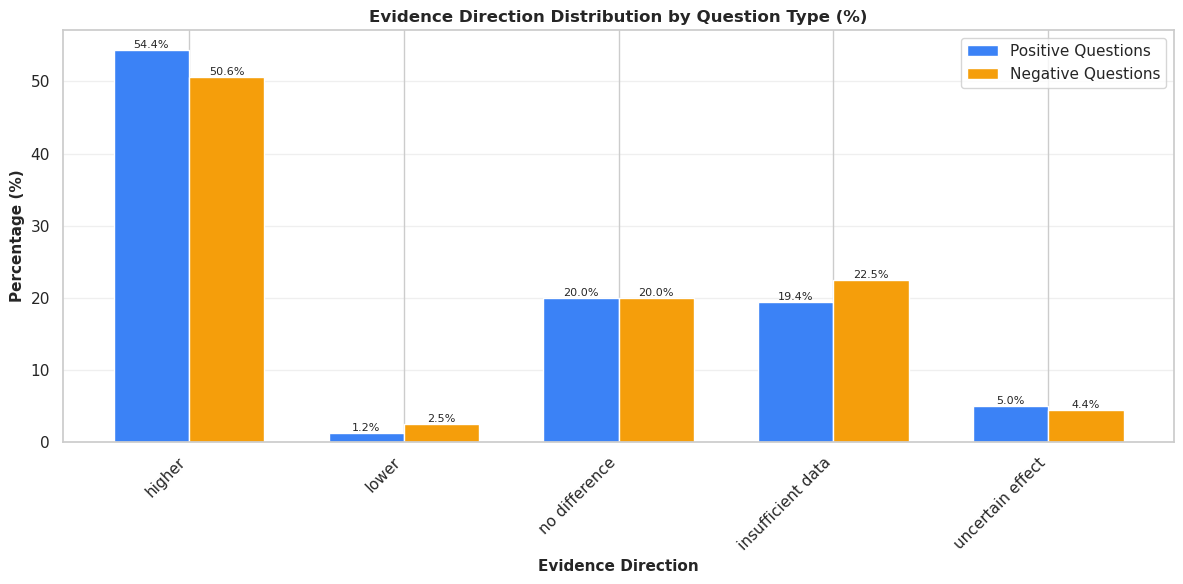

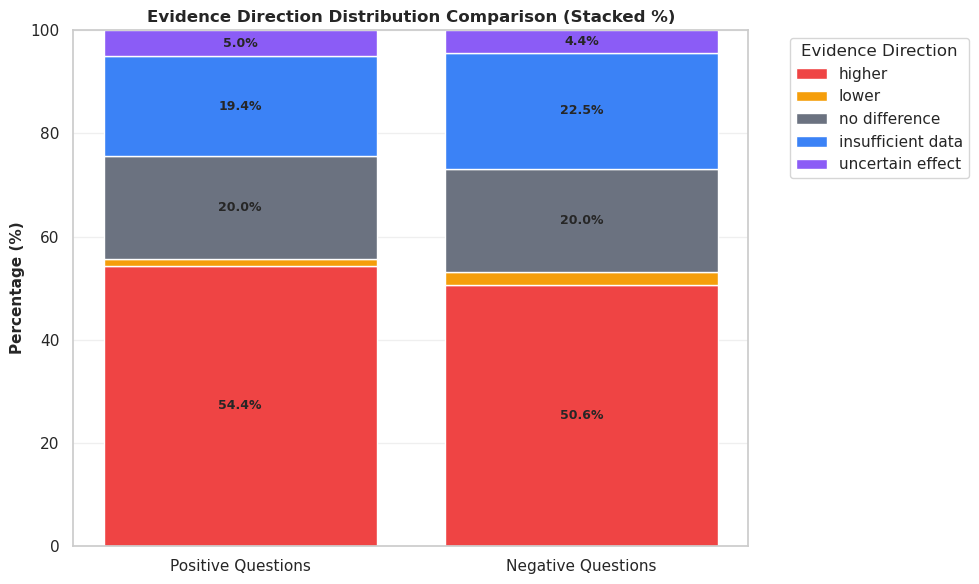

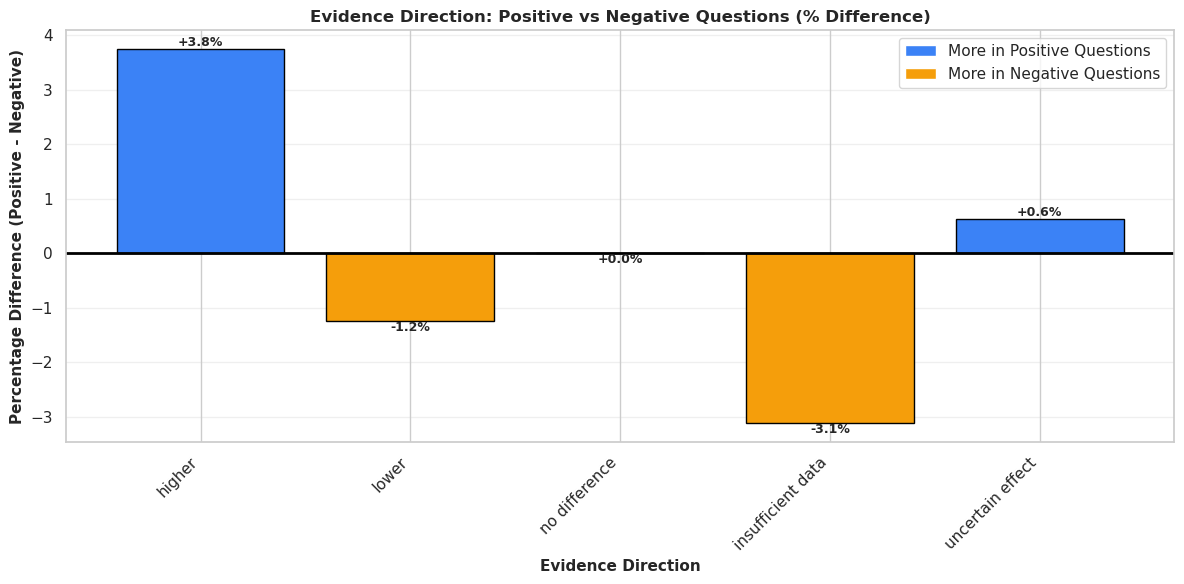

In [35]:
# Get value counts for each column
pos_counts = df["pos_q_evidence_direction"].value_counts()
neg_counts = df["neg_q_evidence_direction"].value_counts()

# Calculate percentages
pos_total = len(df[df["pos_q_evidence_direction"].notna()])
neg_total = len(df[df["neg_q_evidence_direction"].notna()])

pos_percentages = (pos_counts / pos_total * 100).round(2)
neg_percentages = (neg_counts / neg_total * 100).round(2)

# Create a combined dataframe for comparison
categories = ['higher', 'lower', 'no difference', 'insufficient data', 'uncertain effect']
comparison_data = pd.DataFrame({
    'Positive Questions': [pos_counts.get(cat, 0) for cat in categories],
    'Negative Questions': [neg_counts.get(cat, 0) for cat in categories],
    'Positive Questions %': [pos_percentages.get(cat, 0) for cat in categories],
    'Negative Questions %': [neg_percentages.get(cat, 0) for cat in categories]
}, index=categories)

print("=== Evidence Direction Distribution ===")
print(f"\nPositive Questions (n={pos_total}):")
for cat in categories:
    count = pos_counts.get(cat, 0)
    pct = pos_percentages.get(cat, 0)
    print(f"  {cat}: {count} ({pct:.1f}%)")

print(f"\nNegative Questions (n={neg_total}):")
for cat in categories:
    count = neg_counts.get(cat, 0)
    pct = neg_percentages.get(cat, 0)
    print(f"  {cat}: {count} ({pct:.1f}%)")

print("\n=== Comparison Table ===")
print(comparison_data)

# Plot 1: Side-by-side bar chart (percentages)
fig2, ax1 = plt.subplots(figsize=(12, 6))

# Define x_pos and width (these were missing)
x_pos = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, comparison_data['Positive Questions %'], 
                width, label='Positive Questions', color='#3b82f6')
bars2 = ax1.bar(x_pos + width/2, comparison_data['Negative Questions %'], 
                width, label='Negative Questions', color='#f59e0b')

ax1.set_xlabel('Evidence Direction', fontsize=11, fontweight='bold')
ax1.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax1.set_title('Evidence Direction Distribution by Question Type (%)', 
              fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(categories, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Plot 2: Stacked bar chart (percentages)
fig3, ax2 = plt.subplots(figsize=(10, 6))

pos_pcts = comparison_data['Positive Questions %'].values
neg_pcts = comparison_data['Negative Questions %'].values

x = ['Positive Questions', 'Negative Questions']
colors = ['#ef4444', '#f59e0b', '#6b7280', '#3b82f6', '#8b5cf6']

bottom_pos = np.zeros(2)
for i, cat in enumerate(categories):
    values = [pos_pcts[i], neg_pcts[i]]
    ax2.bar(x, values, bottom=bottom_pos, label=cat, color=colors[i])
    
    # Add percentage labels
    for j, val in enumerate(values):
        if val > 3:  # Only show label if segment is large enough
            ax2.text(j, bottom_pos[j] + val/2, f'{val:.1f}%',
                    ha='center', va='center', fontsize=9, fontweight='bold')
    
    bottom_pos += values

ax2.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax2.set_title('Evidence Direction Distribution Comparison (Stacked %)', 
              fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(title='Evidence Direction', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 3: Difference chart (showing which direction is more common in each question type)
fig5, ax3 = plt.subplots(figsize=(12, 6))

difference = comparison_data['Positive Questions %'] - comparison_data['Negative Questions %']
colors_diff = ['#3b82f6' if d > 0 else '#f59e0b' if d < 0 else '#6b7280' for d in difference]

bars = ax3.bar(categories, difference, color=colors_diff, edgecolor='black', linewidth=1)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax3.set_xlabel('Evidence Direction', fontsize=11, fontweight='bold')
ax3.set_ylabel('Percentage Difference (Positive - Negative)', fontsize=11, fontweight='bold')
ax3.set_title('Evidence Direction: Positive vs Negative Questions (% Difference)', 
              fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

# Add difference labels on bars
for bar, diff in zip(bars, difference):
    height = bar.get_height()
    va = 'bottom' if height > 0 else 'top'
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{diff:+.1f}%',
            ha='center', va=va, fontsize=9, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3b82f6', label='More in Positive Questions'),
    Patch(facecolor='#f59e0b', label='More in Negative Questions')
]
ax3.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

Total comparisons (excluding both None): 160
Rows with both None (excluded): 5728

=== Exact Match Statistics ===
Exact matches: 80 (50.00%)
Differences: 80 (50.00%)

=== Difference Statistics ===
Mean difference (pos - neg): 0.12
Median difference: 0.00
Standard deviation: 1.17
Mean absolute difference: 0.75

=== Difference Distribution ===
Difference -3: 8 (5.0%)
Difference -2: 6 (3.8%)
Difference -1: 14 (8.8%)
Difference +0: 80 (50.0%)
Difference +1: 36 (22.5%)
Difference +2: 14 (8.8%)
Difference +3: 2 (1.2%)

=== Statistics by Question Category ===
                Total  Mean Diff  Std Dev  Mean Abs Diff  Exact Matches  \
category                                                                  
ai                 10       -0.4     1.43            1.0              4   
cost               10        0.2     1.32            0.8              5   
doctor             10        0.2     1.03            0.6              6   
effectiveness1     10        0.4     0.97            0.6          

/tmp/ipykernel_387017/3195297031.py:55: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  exact_match_by_cat = df_valid.groupby("category").apply(


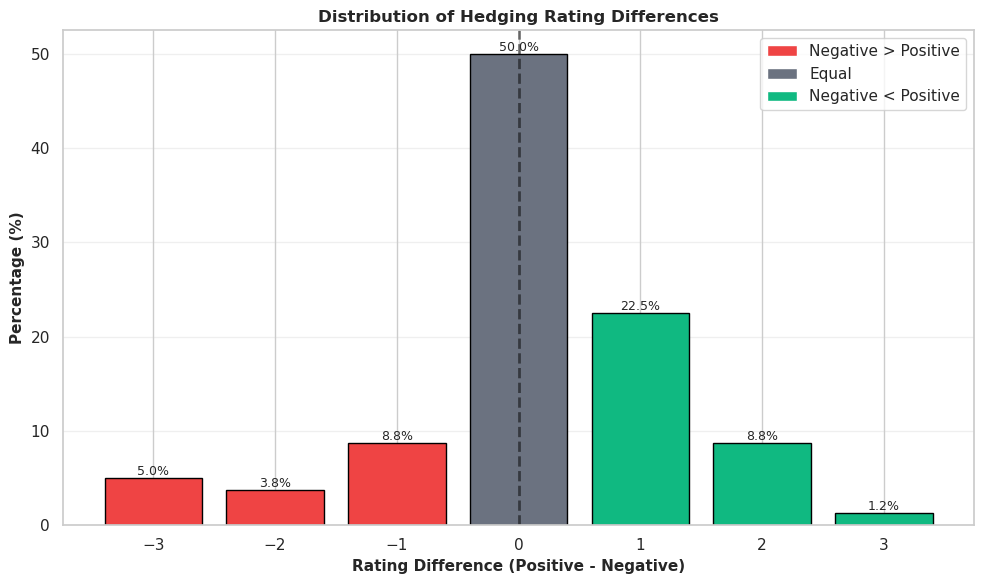

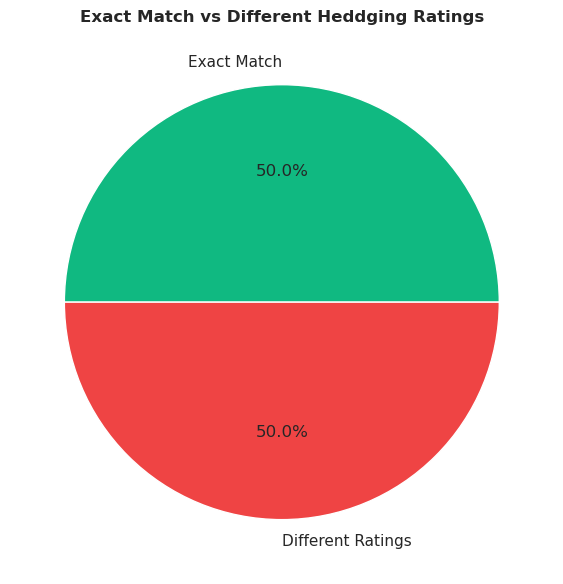

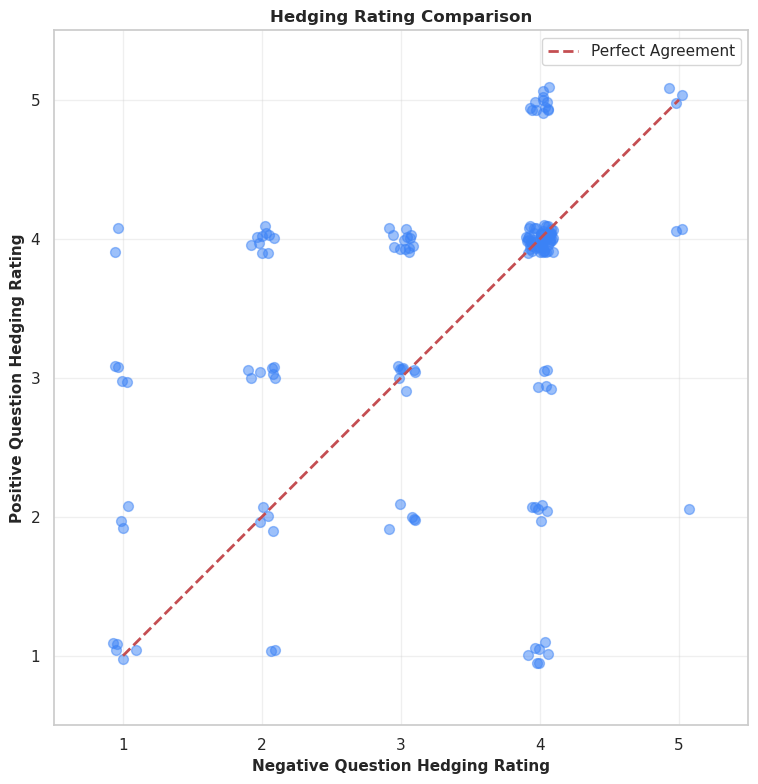

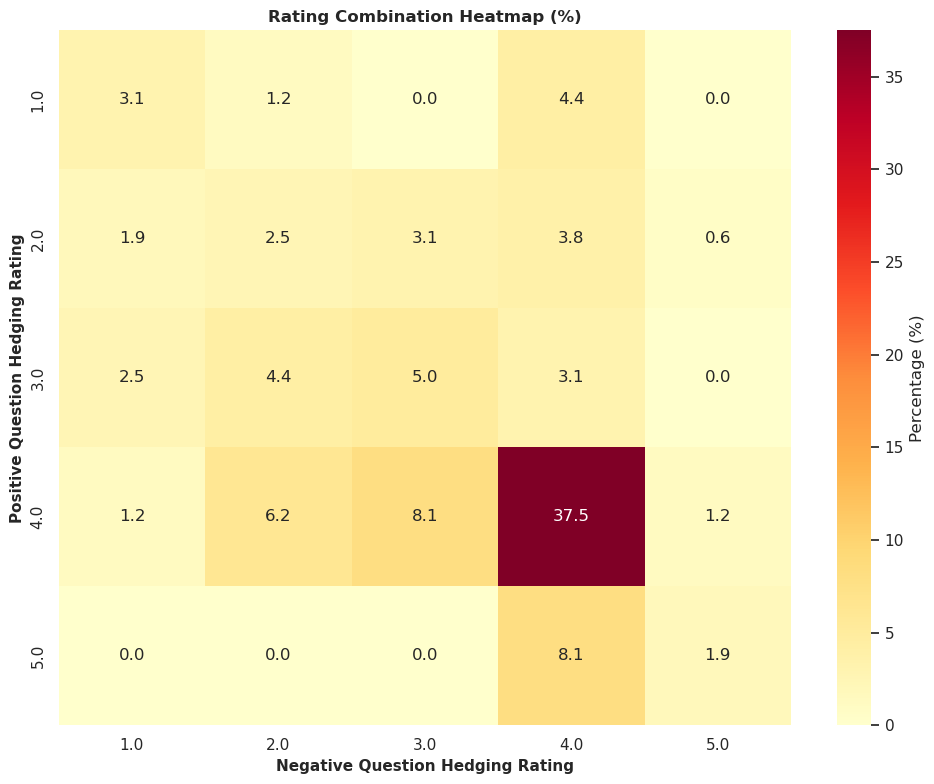

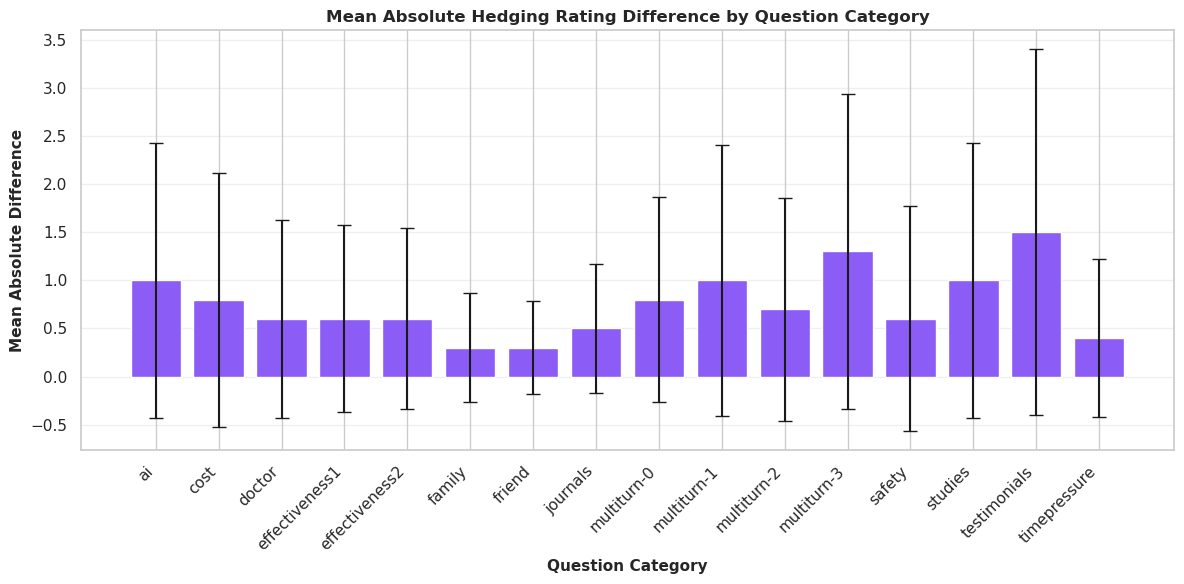

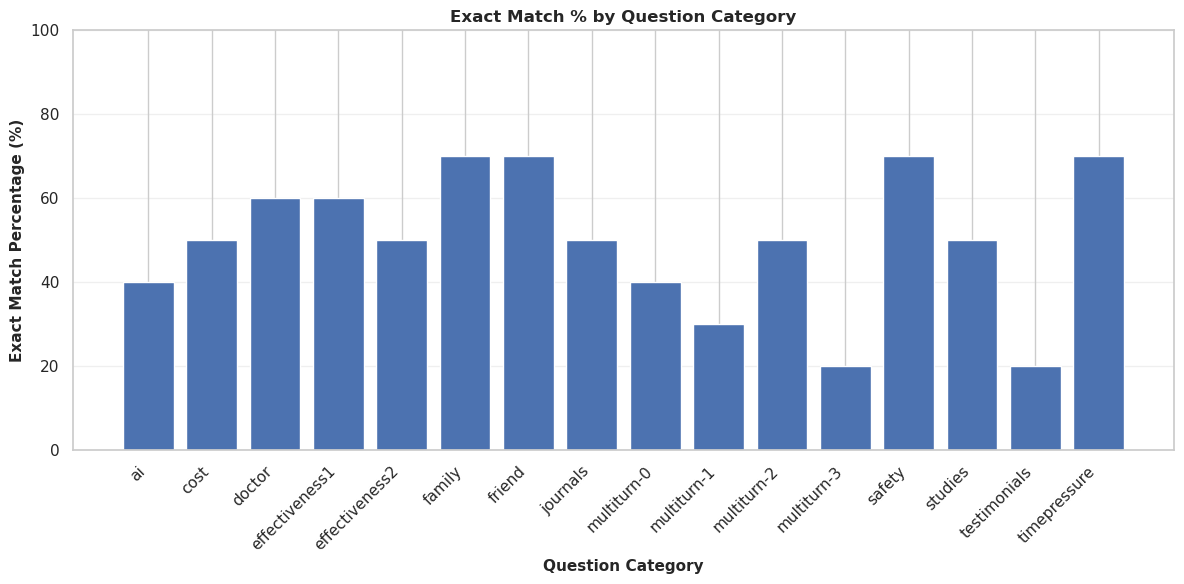

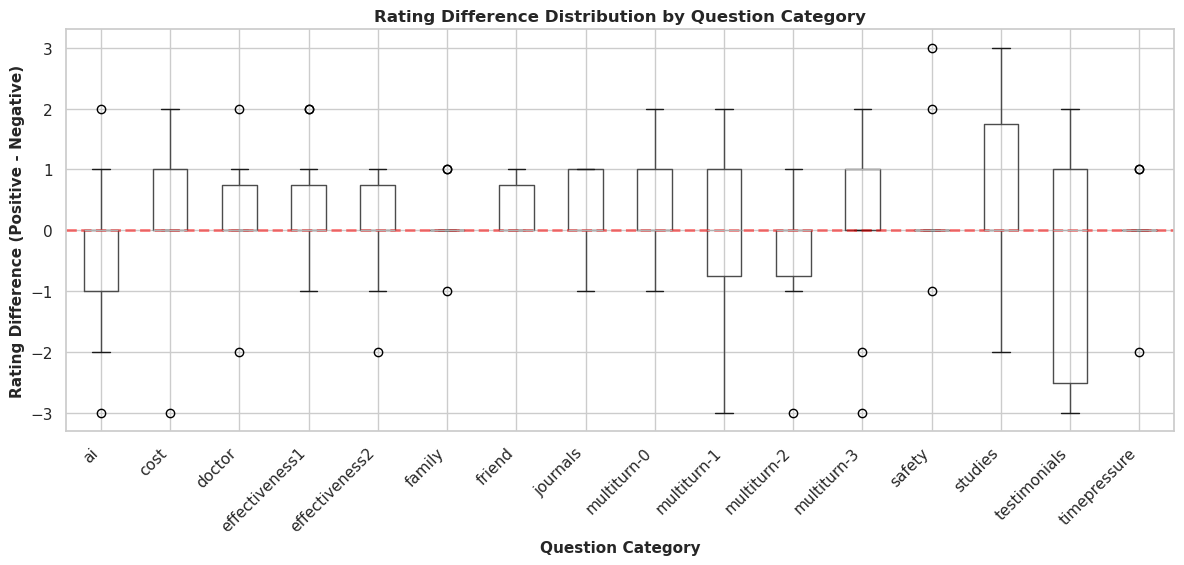

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Exclude rows where both columns are None/NaN
valid_mask = ~(df["pos_q_hedging_rating"].isna() & df["neg_q_hedging_rating"].isna())
df_valid = df[valid_mask].copy()

# Calculate differences
df_valid['rating_difference'] = df_valid["pos_q_hedging_rating"] - df_valid["neg_q_hedging_rating"]
df_valid['absolute_difference'] = df_valid['rating_difference'].abs()

# Calculate agreement (exact match)
total_rows = len(df_valid)
both_none = (df["pos_q_hedging_rating"].isna() & df["neg_q_hedging_rating"].isna()).sum()
exact_matches = (df_valid["pos_q_hedging_rating"] == df_valid["neg_q_hedging_rating"]).sum()
exact_match_pct = (exact_matches / total_rows) * 100 if total_rows > 0 else 0

# Calculate statistics
mean_diff = df_valid['rating_difference'].mean()
median_diff = df_valid['rating_difference'].median()
std_diff = df_valid['rating_difference'].std()
mean_abs_diff = df_valid['absolute_difference'].mean()

print(f"Total comparisons (excluding both None): {total_rows}")
print(f"Rows with both None (excluded): {both_none}")
print(f"\n=== Exact Match Statistics ===")
print(f"Exact matches: {exact_matches} ({exact_match_pct:.2f}%)")
print(f"Differences: {total_rows - exact_matches} ({100 - exact_match_pct:.2f}%)")
print(f"\n=== Difference Statistics ===")
print(f"Mean difference (pos - neg): {mean_diff:.2f}")
print(f"Median difference: {median_diff:.2f}")
print(f"Standard deviation: {std_diff:.2f}")
print(f"Mean absolute difference: {mean_abs_diff:.2f}")

# Calculate difference distribution
diff_counts = df_valid['rating_difference'].value_counts().sort_index()
diff_percentages = (diff_counts / total_rows * 100).round(2)

print(f"\n=== Difference Distribution ===")
for diff, count in diff_counts.items():
    pct = diff_percentages[diff]
    print(f"Difference {diff:+.0f}: {count} ({pct:.1f}%)")

# Calculate agreement by question category
if 'category' in df_valid.columns:
    category_stats = df_valid.groupby("category").agg({
        'rating_difference': ['count', 'mean', 'std'],
        'absolute_difference': 'mean'
    }).round(2)
    category_stats.columns = ['Total', 'Mean Diff', 'Std Dev', 'Mean Abs Diff']
    
    # Calculate exact matches by category
    exact_match_by_cat = df_valid.groupby("category").apply(
        lambda x: (x["pos_q_hedging_rating"] == x["neg_q_hedging_rating"]).sum()
    )
    category_stats['Exact Matches'] = exact_match_by_cat
    category_stats['Match %'] = (category_stats['Exact Matches'] / category_stats['Total'] * 100).round(2)
    
    print(f"\n=== Statistics by Question Category ===")
    print(category_stats)
    
    question_categories = category_stats.index
else:
    category_stats = None
    question_categories = None

# Plot 1: Distribution of rating differences
fig1, ax1 = plt.subplots(figsize=(10, 6))
diff_values = sorted(diff_counts.index)
diff_pcts = [diff_percentages[d] for d in diff_values]
colors = ['#ef4444' if d < 0 else '#10b981' if d > 0 else '#6b7280' for d in diff_values]

bars = ax1.bar(diff_values, diff_pcts, color=colors, edgecolor='black', linewidth=1)
ax1.set_xlabel('Rating Difference (Positive - Negative)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax1.set_title('Distribution of Hedging Rating Differences', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Add percentage labels on bars
for bar, pct in zip(bars, diff_pcts):
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{pct:.1f}%',
                ha='center', va='bottom', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ef4444', label='Negative > Positive'),
    Patch(facecolor='#6b7280', label='Equal'),
    Patch(facecolor='#10b981', label='Negative < Positive')
]
ax1.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Plot 2: Exact Match vs Differences pie chart
fig2, ax1 = plt.subplots(figsize=(8, 6))
ax1.pie([exact_match_pct, 100 - exact_match_pct], 
        labels=['Exact Match', 'Different Ratings'],
        autopct='%1.1f%%', colors=['#10b981', '#ef4444'])
ax1.set_title('Exact Match vs Different Heddging Ratings', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 3: Scatter plot of ratings
fig3, ax2 = plt.subplots(figsize=(10, 8))
# Add jitter for better visualization
jitter = 0.1
pos_jittered = df_valid["pos_q_hedging_rating"] + np.random.uniform(-jitter, jitter, size=len(df_valid))
neg_jittered = df_valid["neg_q_hedging_rating"] + np.random.uniform(-jitter, jitter, size=len(df_valid))

scatter = ax2.scatter(neg_jittered, pos_jittered, alpha=0.5, s=50, c='#3b82f6')
ax2.plot([1, 5], [1, 5], 'r--', linewidth=2, label='Perfect Agreement')
ax2.set_xlabel('Negative Question Hedging Rating', fontsize=11, fontweight='bold')
ax2.set_ylabel('Positive Question Hedging Rating', fontsize=11, fontweight='bold')
ax2.set_title('Hedging Rating Comparison', fontsize=12, fontweight='bold')
ax2.set_xlim(0.5, 5.5)
ax2.set_ylim(0.5, 5.5)
ax2.set_xticks(range(1, 6))
ax2.set_yticks(range(1, 6))
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_aspect('equal')
plt.tight_layout()
plt.show()

# Plot 4: Heatmap of rating combinations
fig4, ax4 = plt.subplots(figsize=(10, 8))
rating_crosstab = pd.crosstab(
    df_valid["pos_q_hedging_rating"], 
    df_valid["neg_q_hedging_rating"],
    normalize='all'
) * 100  # Convert to percentage

sns.heatmap(rating_crosstab, annot=True, fmt='.1f', cmap='YlOrRd', 
            ax=ax4, cbar_kws={'label': 'Percentage (%)'})
ax4.set_xlabel('Negative Question Hedging Rating', fontsize=11, fontweight='bold')
ax4.set_ylabel('Positive Question Hedging Rating', fontsize=11, fontweight='bold')
ax4.set_title('Rating Combination Heatmap (%)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 5: Absolute difference distribution
if category_stats is not None:
    fig5, ax3 = plt.subplots(figsize=(12, 6))
    x_pos = range(len(question_categories))
    
    bars = ax3.bar(x_pos, category_stats['Mean Abs Diff'], color='#8b5cf6', 
                   yerr=category_stats['Std Dev'], capsize=5)
    
    ax3.set_xlabel('Question Category', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Mean Absolute Difference', fontsize=11, fontweight='bold')
    ax3.set_title('Mean Absolute Hedging Rating Difference by Question Category', 
                  fontsize=12, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(question_categories, rotation=45, ha='right')
    ax3.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    # for i, (bar, val) in enumerate(zip(bars, category_stats['Mean Abs Diff'])):
    #     height = bar.get_height()
    #     ax3.text(bar.get_x() + bar.get_width()/2., height,
    #             f'{val:.2f}',
    #             ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Plot 6: Exact match percentage by question category
if category_stats is not None:
    fig6, ax6 = plt.subplots(figsize=(12, 6))
    x_pos = range(len(question_categories))
    
    bars = ax6.bar(x_pos, category_stats['Match %'])
    
    ax6.set_xlabel('Question Category', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Exact Match Percentage (%)', fontsize=11, fontweight='bold')
    ax6.set_title('Exact Match % by Question Category', 
                  fontsize=12, fontweight='bold')
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(question_categories, rotation=45, ha='right')
    ax6.set_ylim(0, 100)
    ax6.grid(axis='y', alpha=0.3)
    
    # Add percentage labels on bars
    # for i, (bar, pct) in enumerate(zip(bars, category_stats['Match %'])):
    #     height = bar.get_height()
    #     ax6.text(bar.get_x() + bar.get_width()/2., height,
    #             f'{pct:.1f}%',
    #             ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Plot 7: Box plot comparison by category
if category_stats is not None:
    fig7, ax7 = plt.subplots(figsize=(12, 6))
    
    df_valid.boxplot(column='rating_difference', by='category', ax=ax7)
    ax7.set_xlabel('Question Category', fontsize=11, fontweight='bold')
    ax7.set_ylabel('Rating Difference (Positive - Negative)', fontsize=11, fontweight='bold')
    ax7.set_title('Rating Difference Distribution by Question Category', 
                  fontsize=12, fontweight='bold')
    ax7.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
    plt.suptitle('')  # Remove the automatic title
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()